# Datos altamente dimensionales
## Vecinos próximos y maldición de la dimensionalidad. 
Esta maldición aparace cuando estamos trabajando con modelos que requieren un gran volúmen de datos. Ya sea cantidad de registros o de columnas.

Este problema es fácil de identificar cuando se usa el método e los vécinos más cercanos ya que estos presentan problemas a la alta dimensionalidad de los datos. 
 

In [1]:
import numpy as np
from sklearn import datasets

iris_X, iris_y = datasets.load_iris(return_X_y=True)
np.unique(iris_y)

array([0, 1, 2])

In [2]:
# Los datos son divididos en entrenamiento y prueba
# Los datos son permutados aleatoriamente.
np.random.seed(0)
indices = np.random.permutation(len(iris_X))

iris_X_train = iris_X[indices[:-10]]
iris_y_train = iris_y[indices[:-10]]
iris_X_test = iris_X[indices[-10:]]
iris_y_test = iris_y[indices[-10:]]

# Se crea un clasificador k-NN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier() # creación del clasificador de vecinos más cercanos
# lo entrenamos
knn.fit(
    iris_X_train,
    iris_y_train,
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [3]:
# Pronóstico para el conjunto de test
display(
    knn.predict(iris_X_test),
    iris_y_test,
)

array([1, 2, 1, 0, 0, 0, 2, 1, 2, 0])

array([1, 1, 1, 0, 0, 0, 2, 1, 2, 0])

Maldición de la dimensionalidad:

* Para que el estimador sea efectivo, se requiere que la distancia entre vecinos sea menor que un valor ‘d’.

* En una dimensión se requiere en promedio n ~ 1/d puntos para cubrir el espacio. d sería aproximadamente 1/n reaprtiendo la distancia entre los n puntos por ello es que n ~ 1/d

Un ejemplo numérico rápido: Si quieres que tus puntos en la línea estén tan juntos que el espacio entre vecinos ($d$) sea de $0.1$ unidades (un $10\%$ del espacio total):

$$n \approx \frac{1}{0.1} = 10 \text{ puntos}$$

Si deseas duplicar la densidad  para que la distancia $d$ sea de solo $0.01$ unidades:$$n \approx \frac{1}{0.01} = 100 \text{ puntos}$$

* Si se tienen p dimensiones se requiere en promedio n ~ 1/d^p puntos para cubrir el espacio.

* Si se requieren 10 puntos en una dimensión, para 5 dimensiones se requieren 10^5 puntos.

* La cantidad de puntos crece exponencialmente con la cantidad de dimensiones.

En 1 dimensión, cubrir el espacio crece linealmente ($n \sim \frac{1}{d}$).Sin embargo, en $D$ dimensiones, para mantener esa misma densidad de vecinos $d$ a lo largo de cada eje (por ejemplo, en un cuadrado $2D$ o en un cubo $3D$), la cantidad de puntos requerida explota exponencialmente:

$$n \approx \left(\frac{1}{d}\right)^D$$

En 1D con $d = 0.1$: necesitas $10^1 = \mathbf{10}$ puntos.En 2D con $d = 0.1$: necesitas $10^2 = \mathbf{100}$ puntos.En 10D con $d = 0.1$: necesitas $10^{10} = \mathbf{10,000,000,000}$ puntos.Esto explica por qué algoritmos basados en distancias locales como KNN pierden efectividad en dimensiones elevadas: el espacio se vuelve tan gigante y disperso que los "vecinos más cercanos" terminan estando sumamente lejos.

Imagina una calle de 10 metros donde pones 10 postes para iluminarla bien (1D), pero si esa calle se convierte en una plaza cuadrada de 10×10 metros, necesitas 100 postes para cubrirla con la misma densidad (2D), y si pasa a ser un edificio cúbico de 10×10×10 metros, requerirás 1,000 postes (3D); en dimensiones altas ocurre exactamente esta multiplicación exponencial del espacio, de modo que si solo tienes 1,000 datos en 10D, es el equivalente a esparcir 1,000 granos de arena en un estadio gigantesco: los datos quedan completamente aislados en medio del vacío y pierde sentido buscar "vecinos cercanos".

Por tanto, la maldición de la dimensionalidad es el hecho de que a medida que se incluyan más dimenisiones, no se necestian más puntos de manera lineal, como pensar de una manera proporcional, se necesitan más puntos a manera exponencial, lo cual deja ser viable. 

## Modelos lineales


In [4]:
#
# Carga del dataset de diabetes
# Llamar datos
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

#Primero datos en entrenamiento y últimos 20 en test
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

#Primeeros 20 de entrenamiento y y los últimos 20 en test
#cabe recalcar que los datos son exactos entre ellos
# es decir la partición de entrenamiento contra prueba es perfecta. 
diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

In [5]:
#
# Regresión lineal
#
from sklearn import linear_model

regr = linear_model.LinearRegression() #instancia de un objeto de tipo de regreisón 
# lineal

# cálculo d elos estimadores de regresión lineal. 
regr.fit(diabetes_X_train, diabetes_y_train)
regr.coef_ # ver los coeficientes. 

array([ 3.06094248e-01, -2.37635570e+02,  5.10538048e+02,  3.27729878e+02,
       -8.14111926e+02,  4.92799595e+02,  1.02841240e+02,  1.84603496e+02,
        7.43509388e+02,  7.60966464e+01])

In [6]:
#
# Error cuadrático medio
#
np.mean((regr.predict(diabetes_X_test) - diabetes_y_test) ** 2)

np.float64(2004.5186863342096)

In [7]:
#
# Explained variance score: 1 es la predicción perfecta
# y 0 significa que no hay relación lineal entre x y y.
#
regr.score(diabetes_X_test, diabetes_y_test)

0.585085427447195

In [12]:
#
# Shrinkage: pocos puntos por dimension induce una alta varianza en los 
# coeficientes del modelo
#

#creamos una recta de 45 grados. 
X = np.c_[0.5, 1].T
y = [0.5, 1]
test = np.c_[0, 2].T
regr = linear_model.LinearRegression()

In [9]:
np.c_[0.5, 1]

array([[0.5, 1. ]])

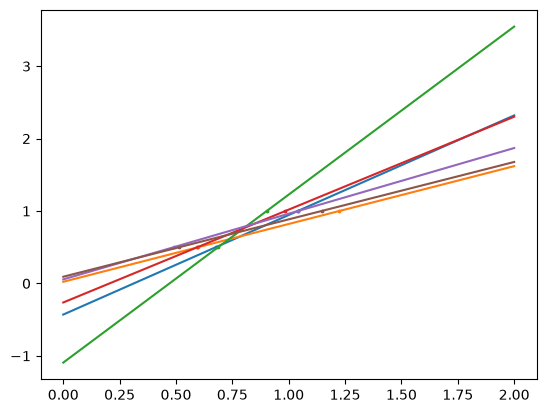

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
np.random.seed(0)
# distintintas reglas para hallar el modelo real
for _ in range(6):

    # 6 rectas donde el X original se le suma 
    # un ruido normal. 
    this_X = 0.1 * np.random.normal(size=(2, 1)) + X

    #entrenamos el modelo
    regr.fit(this_X, y)

    # gráficar el modelo con el X de test y la predicción
    plt.plot(test, regr.predict(test))

    # graficar pntos del modelo. 
    plt.scatter(this_X, y, s=3)

In [10]:
np.random.normal(size=(2,1))


array([[-0.57890879],
       [ 1.42694855]])

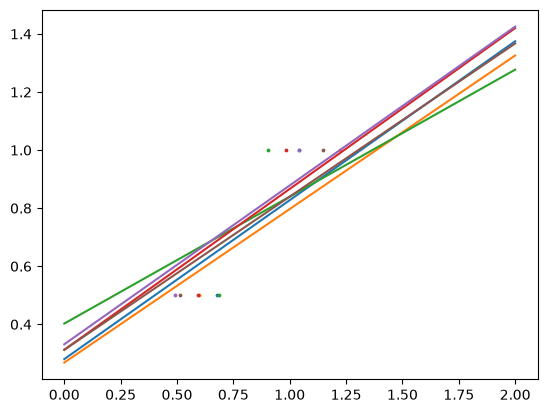

In [16]:
#
# Una solución para aprendizaje estadístico altamente
# dimensional es llevar los coeficientes a cero.
# Este es un ejemplo del dilema sesgo-varianza.
# La regresión ridge penaliza los coeficientes
# para que se vayan reduciendo para controlar la varianza
# aunque esto empieza a generar sesgo. 
regr = linear_model.Ridge(alpha=0.1)
# alpha = 0 es la regresión lineal normal. 

plt.figure()
np.random.seed(0)
for _ in range(6):
    this_X = 0.1 * np.random.normal(size=(2, 1)) + X
    regr.fit(this_X, y)
    plt.plot(test, regr.predict(test))
    plt.scatter(this_X, y, s=3)

In [ ]:
#
# Se construye una malla para escoger el valor optimo del
# hiperparámetro alpha
#
alphas = np.logspace(-4, -1, 6)
# Hacemos un lsit comprenhension de los valores
# del modelo de regresión, lo ajustamos yu calculamos el score
# para ver su comportamiento con los diferentes alphas. 
# y la idea es escoger el que maximize el score. 
[
    regr.set_params(alpha=alpha)
    .fit(diabetes_X_train, diabetes_y_train)
    .score(diabetes_X_test, diabetes_y_test)
    for alpha in alphas
]

# Máquinas de vectores de soporte

In [ ]:
# para clasificación. 
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

iris = datasets.load_iris()
# Se toman unicamente las dos primeras dimensiones para
# convertir el problema a 2D
X = iris.data[:, :2]
y = iris.target

# Se crea una instancia de una SVM y se entrena con los datos.
# Los datos no se escalan.
C = 1.0  # Parámetro de regularización.
# usamos 4 máquinas de soporte vectorial que se diferencian
# en el kernel que usan para la estimación del Y. 
models = (
    # frontereas lienales
    svm.SVC(kernel="linear", C=C),

    # fronteras lineales
    svm.LinearSVC(C=C, max_iter=10000, dual="auto"),

    # MODELOS PARA FRONTERAS NO LINEALES. 
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
)

# ajustar los modelos
models = (clf.fit(X, y) for clf in models)

# Titulo de las gráficas
titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

# Grafica de 2x2
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

# ax es el eje de esa matriz 4x4 donde se va a
# a graficar. 
for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        # en el eje Y lso pronósticos
        response_method="predict",

        # colores
        cmap=plt.cm.coolwarm,

        # transparencia
        alpha=0.8,

        # ejes
        ax=ax,

        # nombres de los ejes
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
    )

    # puntos de dispersión
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()